## Visualizing Lasso vs Ridge Geometry

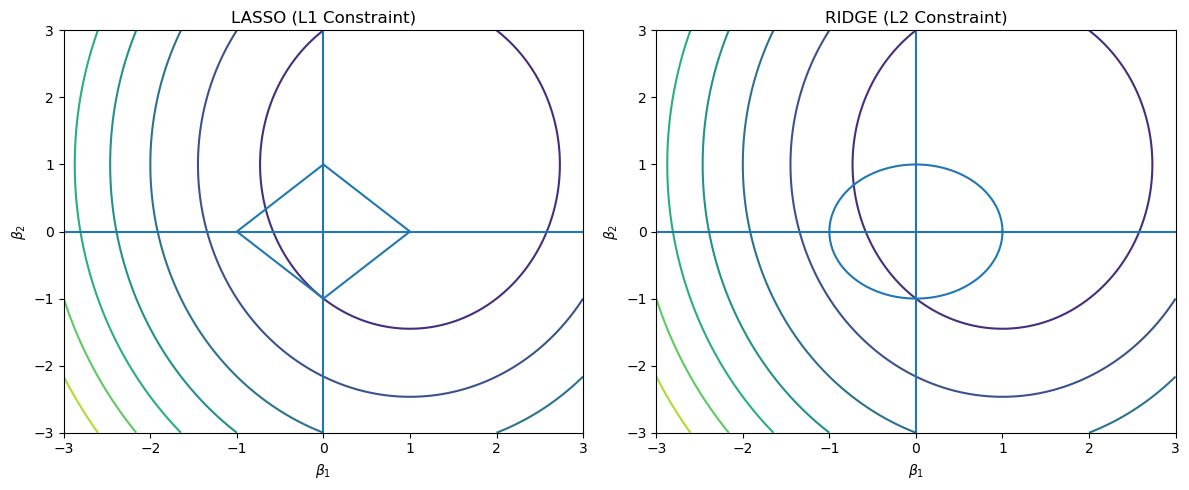

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

# Elliptical RSS contours
Z = (X - 1)**2 + 0.5*(Y - 1)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------------- LASSO ----------------
axes[0].contour(X, Y, Z, levels=8)
axes[0].plot([0, 1, 0, -1, 0], [1, 0, -1, 0, 1])  # L1 diamond
axes[0].set_title("LASSO (L1 Constraint)")
axes[0].set_xlabel(r"$\beta_1$")
axes[0].set_ylabel(r"$\beta_2$")
axes[0].axhline(0)
axes[0].axvline(0)

# ---------------- RIDGE ----------------
axes[1].contour(X, Y, Z, levels=8)
theta = np.linspace(0, 2*np.pi, 200)
axes[1].plot(np.cos(theta), np.sin(theta))  # L2 circle
axes[1].set_title("RIDGE (L2 Constraint)")
axes[1].set_xlabel(r"$\beta_1$")
axes[1].set_ylabel(r"$\beta_2$")
axes[1].axhline(0)
axes[1].axvline(0)

plt.tight_layout()
plt.show()


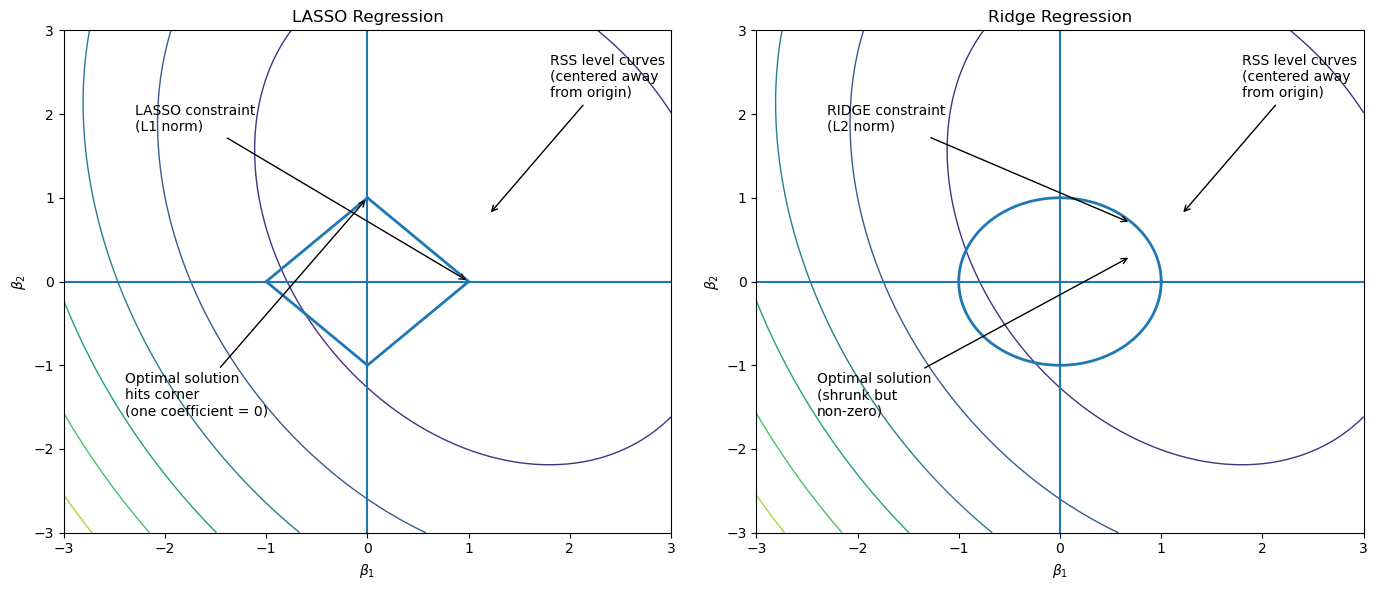

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Create grid for contours
# -------------------------------
x = np.linspace(-3, 3, 500)
y = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x, y)

# Tilted elliptical RSS contours (centered away from origin)
Z = (
    (X - 1.2)**2
    + 0.6 * (Y - 0.8)**2
    + 0.4 * (X - 1.2) * (Y - 0.8)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================================================
# LASSO (L1)
# =========================================================
axes[0].contour(X, Y, Z, levels=6, linewidths=1)

# L1 constraint (diamond)
diamond_x = [0, 1, 0, -1, 0]
diamond_y = [1, 0, -1, 0, 1]
axes[0].plot(diamond_x, diamond_y, linewidth=2)

# Axes
axes[0].axhline(0)
axes[0].axvline(0)

# Annotations
axes[0].annotate(
    "RSS level curves\n(centered away\nfrom origin)",
    xy=(1.2, 0.8),
    xytext=(1.8, 2.2),
    arrowprops=dict(arrowstyle="->")
)

axes[0].annotate(
    "LASSO constraint\n(L1 norm)",
    xy=(1, 0),
    xytext=(-2.3, 1.8),
    arrowprops=dict(arrowstyle="->")
)

axes[0].annotate(
    "Optimal solution\nhits corner\n(one coefficient = 0)",
    xy=(0, 1),
    xytext=(-2.4, -1.6),
    arrowprops=dict(arrowstyle="->")
)

axes[0].set_title("LASSO Regression")
axes[0].set_xlabel(r"$\beta_1$")
axes[0].set_ylabel(r"$\beta_2$")
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)

# =========================================================
# RIDGE (L2)
# =========================================================
axes[1].contour(X, Y, Z, levels=6, linewidths=1)

# L2 constraint (circle)
theta = np.linspace(0, 2*np.pi, 400)
axes[1].plot(np.cos(theta), np.sin(theta), linewidth=2)

# Axes
axes[1].axhline(0)
axes[1].axvline(0)

# Annotations
axes[1].annotate(
    "RSS level curves\n(centered away\nfrom origin)",
    xy=(1.2, 0.8),
    xytext=(1.8, 2.2),
    arrowprops=dict(arrowstyle="->")
)

axes[1].annotate(
    "RIDGE constraint\n(L2 norm)",
    xy=(0.7, 0.7),
    xytext=(-2.3, 1.8),
    arrowprops=dict(arrowstyle="->")
)

axes[1].annotate(
    "Optimal solution\n(shrunk but\nnon-zero)",
    xy=(0.7, 0.3),
    xytext=(-2.4, -1.6),
    arrowprops=dict(arrowstyle="->")
)

axes[1].set_title("Ridge Regression")
axes[1].set_xlabel(r"$\beta_1$")
axes[1].set_ylabel(r"$\beta_2$")
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)

plt.tight_layout()
plt.show()


“The L1 constraint has corners, causing the optimal solution to lie on axes and produce zero coefficients, whereas the smooth L2 constraint results in coefficient shrinkage without sparsity.”

## Elastic Net Regression

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


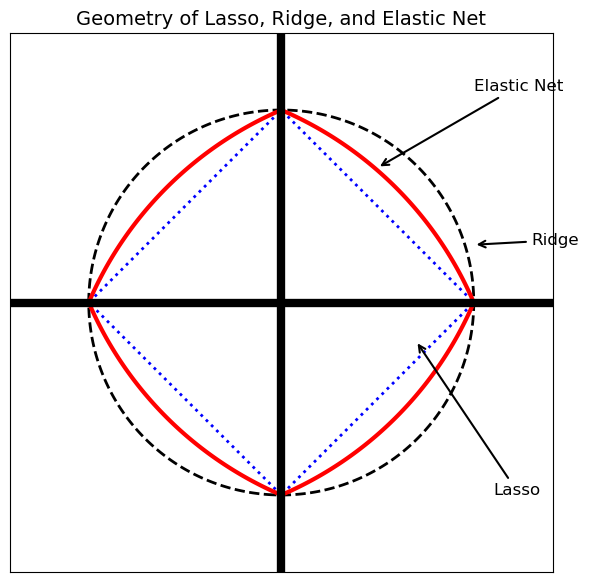

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(-1.5, 1.5, 600)
y = np.linspace(-1.5, 1.5, 600)
X, Y = np.meshgrid(x, y)

# Parameters
alpha = 0.6   # Elastic Net mixing
c = 1.0

# Constraints
ridge = X**2 + Y**2
lasso = np.abs(X) + np.abs(Y)
elastic = alpha * lasso + (1 - alpha) * ridge

plt.figure(figsize=(7, 7))

# Ridge (circle)
plt.contour(X, Y, ridge, levels=[c], linestyles='--', linewidths=2, colors='black')

# Lasso (diamond)
plt.contour(X, Y, lasso, levels=[c], linestyles=':', linewidths=2, colors='blue')

# Elastic Net (rounded diamond)
plt.contour(X, Y, elastic, levels=[c], linewidths=3, colors='red')

# Thick axes
plt.axhline(0, color='black', linewidth=6)
plt.axvline(0, color='black', linewidth=6)

# Labels
plt.annotate("Elastic Net", xy=(0.5, 0.7), xytext=(1.0, 1.1),
             arrowprops=dict(arrowstyle="->", linewidth=1.5), fontsize=12)

plt.annotate("Ridge", xy=(1.0, 0.3), xytext=(1.3, 0.3),
             arrowprops=dict(arrowstyle="->", linewidth=1.5), fontsize=12)

plt.annotate("Lasso", xy=(0.7, -0.2), xytext=(1.1, -1.0),
             arrowprops=dict(arrowstyle="->", linewidth=1.5), fontsize=12)

plt.axis("equal")
plt.xlim(-1.4, 1.4)
plt.ylim(-1.4, 1.4)
plt.xticks([])
plt.yticks([])

plt.title("Geometry of Lasso, Ridge, and Elastic Net", fontsize=14)
plt.show()
